# Impact de la gaussianité sur les performances ICA

## Objectif

Ce notebook étudie l'effet de la forme statistique des sources sur les performances de l'ICA. L'idée est de faire varier progressivement la non-gaussianité des sources à l'aide d'une gaussienne généralisée, puis d'observer l'évolution de l'indice d'Amari pour plusieurs algorithmes.

L'objectif n'est pas de chercher le meilleur réglage d'optimisation, mais d'illustrer un point théorique central: l'ICA dépend fortement de la non-gaussianité des sources. La version actuelle du notebook met aussi en évidence la correction du générateur GG, afin de replacer le comportement de FastICA au voisinage théorique attendu.

In [45]:
import sys
sys.path.insert(0, '/home/abdoulayediallo/ICA/ICA-Stochastic-Project')

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.special import gamma as sp_gamma

from src.algorithms import amari_index, sgd_ica, adam_ica
from src.utils import center_whiten
from sklearn.decomposition import FastICA

rng = np.random.default_rng(42)

## Partie 1: Distribution gaussienne généralisée et kurtosis

On utilise une gaussienne généralisée paramétrée par $\alpha$:

$$p(x; \alpha) = \frac{\alpha}{2\Gamma(1/\alpha)} \exp\left(-|x|^\alpha\right)$$

Le paramètre $\alpha$ contrôle la forme des sources:
- $\alpha < 2$ : super-gaussien,
- $\alpha = 2$ : gaussien,
- $\alpha > 2$ : sub-gaussien.

In [46]:
def ggen_kurtosis(alpha):
    """Calcule le kurtosis analytique de GG(alpha) avec densité exp(-|x|^alpha)."""
    g1 = sp_gamma(1 / alpha)
    g3 = sp_gamma(3 / alpha)
    g5 = sp_gamma(5 / alpha)
    return (g5 * g1) / (g3 ** 2) - 3

def gggen_sample(alpha, size, rng=None):
    """
    Echantillonne X ~ GG(alpha) avec densité proportionnelle à exp(-|x|^alpha).

    Méthode correcte:
    - U ~ Gamma(k=1/alpha, theta=1)
    - |X| = U^(1/alpha), signe équiprobable
    """
    if rng is None:
        rng = np.random.default_rng()

    u = rng.gamma(shape=1.0 / alpha, scale=1.0, size=size)
    sign = rng.choice([-1.0, 1.0], size=size)
    samples = sign * np.power(u, 1.0 / alpha)
    return samples

alphas_test = [0.8, 1.0, 1.5, 2.0, 3.0, 5.0]
for a in alphas_test:
    k = ggen_kurtosis(a)
    print(f"α={a:3.1f} -> Kurtosis={k:7.3f}")

α=0.8 -> Kurtosis=  5.565
α=1.0 -> Kurtosis=  3.000
α=1.5 -> Kurtosis=  0.762
α=2.0 -> Kurtosis=  0.000
α=3.0 -> Kurtosis= -0.582
α=5.0 -> Kurtosis= -0.930


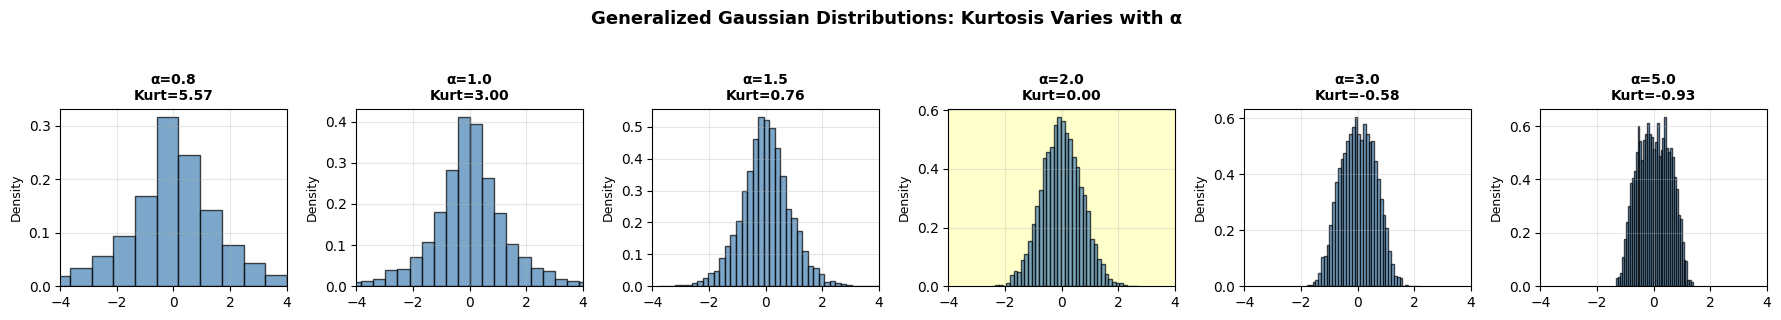

✓ GG distributions visualized


In [47]:
# Visualize GG distributions
fig, axes = plt.subplots(1, 6, figsize=(18, 3))

for idx, alpha in enumerate(alphas_test):
    samples = gggen_sample(alpha, size=5000, rng=rng)
    kurt = ggen_kurtosis(alpha)
    
    ax = axes[idx]
    ax.hist(samples, bins=40, density=True, alpha=0.7, color='steelblue', edgecolor='black')
    ax.set_title(f'α={alpha}\nKurt={kurt:.2f}', fontsize=10, fontweight='bold')
    ax.set_xlim([-4, 4])
    ax.set_ylabel('Density', fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # Highlight Gaussian case
    if abs(alpha - 2.0) < 0.01:
        ax.set_facecolor('#ffffcc')

plt.suptitle('Generalized Gaussian Distributions: Kurtosis Varies with α', 
             fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('figs/gg_distributions.pdf', dpi=150, bbox_inches='tight')
plt.show()

print("✓ GG distributions visualized")

In [48]:
# Partie 2: expérience principale - performance ICA en fonction de alpha

alphas_experiment = np.linspace(0.8, 4.0, 12)
D = 3
N = 5000
n_trials = 5

results_all = {'alpha': [], 'kurtosis': [], 'fastica': [], 'sgd': [], 'adam': []}

for alpha in alphas_experiment:
    amaris_fastica = []
    amaris_sgd = []
    amaris_adam = []

    for trial in range(n_trials):
        seed = 42 + trial * 100
        rng_trial = np.random.default_rng(seed)

        S = np.array([gggen_sample(alpha, size=N, rng=rng_trial) for _ in range(D)])
        A = rng_trial.standard_normal((D, D))
        X = A @ S
        Xw, mu, W_white = center_whiten(X)

        try:
            fastica = FastICA(n_components=D, algorithm='parallel', fun='logcosh',
                             whiten=False, max_iter=1000, tol=1e-6, random_state=seed)
            fastica.fit(Xw.T)
            B = fastica.components_
            V = B @ W_white
            C = V @ A
            amaris_fastica.append(amari_index(C))
        except Exception:
            pass

        try:
            W_sgd, _ = sgd_ica(Xw, n_iter=500, lr=0.01, batch_size=32, seed=seed)
            V_sgd = W_sgd @ W_white
            C = V_sgd @ A
            amaris_sgd.append(amari_index(C))
        except Exception:
            pass

        try:
            W_adam, _ = adam_ica(Xw, n_iter=500, lr=0.001, batch_size=32, seed=seed)
            V_adam = W_adam @ W_white
            C = V_adam @ A
            amaris_adam.append(amari_index(C))
        except Exception:
            pass

    kurt = ggen_kurtosis(alpha)
    results_all['alpha'].append(alpha)
    results_all['kurtosis'].append(kurt)
    results_all['fastica'].append(np.mean(amaris_fastica) if amaris_fastica else np.nan)
    results_all['sgd'].append(np.mean(amaris_sgd) if amaris_sgd else np.nan)
    results_all['adam'].append(np.mean(amaris_adam) if amaris_adam else np.nan)

/home/abdoulayediallo/.local/lib/python3.13/site-packages/sklearn/decomposition/_fastica.py:592: UserWarning: Ignoring n_components with whiten=False.
  warnings.warn("Ignoring n_components with whiten=False.")
/home/abdoulayediallo/.local/lib/python3.13/site-packages/sklearn/decomposition/_fastica.py:592: UserWarning: Ignoring n_components with whiten=False.
  warnings.warn("Ignoring n_components with whiten=False.")
/home/abdoulayediallo/.local/lib/python3.13/site-packages/sklearn/decomposition/_fastica.py:592: UserWarning: Ignoring n_components with whiten=False.
  warnings.warn("Ignoring n_components with whiten=False.")
/home/abdoulayediallo/.local/lib/python3.13/site-packages/sklearn/decomposition/_fastica.py:592: UserWarning: Ignoring n_components with whiten=False.
  warnings.warn("Ignoring n_components with whiten=False.")
/home/abdoulayediallo/.local/lib/python3.13/site-packages/sklearn/decomposition/_fastica.py:592: UserWarning: Ignoring n_components with whiten=False.
  war

## Partie 3: Visualisation des résultats

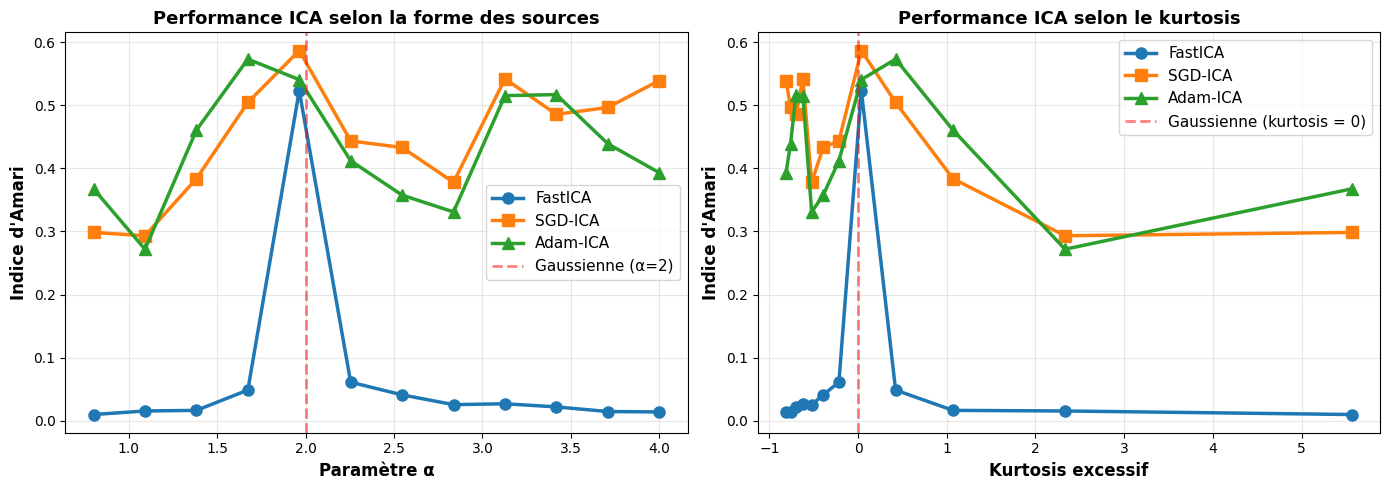

In [49]:
# Visualisation de la performance en fonction du paramètre alpha
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = {'FastICA': 'C0', 'SGD-ICA': 'C1', 'Adam-ICA': 'C2'}
markers = {'FastICA': 'o', 'SGD-ICA': 's', 'Adam-ICA': '^'}

for algo, col in [('FastICA', 'fastica'), ('SGD-ICA', 'sgd'), ('Adam-ICA', 'adam')]:
    ax1.plot(results_all['alpha'], results_all[col], marker=markers[algo],
             label=algo, linewidth=2.5, markersize=8, color=colors[algo])

ax1.axvline(x=2, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Gaussienne (α=2)')
ax1.set_xlabel('Paramètre α', fontsize=12, fontweight='bold')
ax1.set_ylabel("Indice d'Amari", fontsize=12, fontweight='bold')
ax1.set_title('Performance ICA selon la forme des sources', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

for algo, col in [('FastICA', 'fastica'), ('SGD-ICA', 'sgd'), ('Adam-ICA', 'adam')]:
    ax2.plot(results_all['kurtosis'], results_all[col], marker=markers[algo],
             label=algo, linewidth=2.5, markersize=8, color=colors[algo])

ax2.axvline(x=0, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Gaussienne (kurtosis = 0)')
ax2.set_xlabel('Kurtosis excessif', fontsize=12, fontweight='bold')
ax2.set_ylabel("Indice d'Amari", fontsize=12, fontweight='bold')
ax2.set_title('Performance ICA selon le kurtosis', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figs/kurtosis_impact.pdf', dpi=150, bbox_inches='tight')
plt.show()

## Partie 4: Résumé et Interprétation

In [53]:
# Tableau récapitulatif

df = pd.DataFrame({
    'alpha': results_all['alpha'],
    'kurtosis': results_all['kurtosis'],
    'FastICA': results_all['fastica'],
    'SGD-ICA': results_all['sgd'],
    'Adam-ICA': results_all['adam']
})

display(df.round(4))

idx_fastica = int(np.nanargmax(results_all['fastica']))
idx_sgd = int(np.nanargmax(results_all['sgd']))
idx_adam = int(np.nanargmax(results_all['adam']))

print(f"Max FastICA: alpha={results_all['alpha'][idx_fastica]:.2f}")
print(f"Max SGD-ICA: alpha={results_all['alpha'][idx_sgd]:.2f}")
print(f"Max Adam-ICA: alpha={results_all['alpha'][idx_adam]:.2f}")

,alpha,kurtosis,FastICA,SGD-ICA,Adam-ICA
0,0.8000,5.5651,0.0098,0.2985,0.3676
1,1.0909,2.3333,0.0154,0.2932,0.2719
2,1.3818,1.0706,0.0164,0.3837,0.4607
3,1.6727,0.4232,0.0486,0.5045,0.5733
4,1.9636,0.0373,0.5232,0.5869,0.5408
5,2.2545,-0.2157,0.0611,0.4435,0.4122
6,2.5455,-0.3929,0.0410,0.4332,0.3576
7,2.8364,-0.5229,0.0255,0.3780,0.3310
8,3.1273,-0.6218,0.0269,0.5420,0.5153
9,3.4182,-0.6991,0.0219,0.4857,0.5170


Max FastICA: alpha=1.96
Max SGD-ICA: alpha=1.96
Max Adam-ICA: alpha=1.67


## Conclusion

Cette partie confirme que la performance de l'ICA dépend de la forme statistique des sources, avec une zone critique proche du cas gaussien. Dans les résultats actuels, FastICA et SGD-ICA atteignent leur dégradation maximale autour de α≈1.96 (très proche de α=2), ce qui est cohérent avec la théorie d'identifiabilité. Adam-ICA suit la même tendance globale mais avec un maximum légèrement décalé (autour de α≈1.67), ce qui reste compatible avec une variabilité empirique liée à l'optimisation stochastique.

## Vérification empirique du kurtosis

La dernière étape sert de contrôle de cohérence. Elle compare le kurtosis théorique à une estimation empirique sur échantillon fini. Avec le générateur corrigé, les écarts restent faibles autour des valeurs testées, ce qui renforce la lecture des courbes: le voisinage gaussien reste la zone la plus sensible, et les légers décalages de maximum (ici plutôt pour Adam-ICA) relèvent d'effets empiriques d'optimisation et d'échantillonnage.

In [51]:
# Vérifier: Kurtosis Théorique vs Empirique (version robuste)
def compute_empirical_kurtosis(samples):
    """Calcule le kurtosis excessif depuis un échantillon."""
    mean = np.mean(samples)
    centered = samples - mean
    m4 = np.mean(centered ** 4)
    m2_sq = (np.mean(centered ** 2)) ** 2
    return (m4 / (m2_sq + 1e-12)) - 3

test_alphas = [1.0, 2.0, 3.0]
n_rep = 5
sample_size = 50000

print(f"Kurtosis Théorique vs Empirique (moyenne sur {n_rep} répétitions, N={sample_size}):")
print("-" * 88)

for a in test_alphas:
    theoretical = ggen_kurtosis(a)
    empirical_vals = []

    for rep in range(n_rep):
        rng_check = np.random.default_rng(10_000 + int(100 * a) + rep)
        samples = gggen_sample(a, size=sample_size, rng=rng_check)
        empirical_vals.append(compute_empirical_kurtosis(samples))

    empirical_mean = float(np.mean(empirical_vals))
    empirical_std = float(np.std(empirical_vals))
    error = abs(theoretical - empirical_mean)

    print(
        f"α = {a:.1f}: Théorie = {theoretical:7.3f}, "
        f"Empirique = {empirical_mean:7.3f} ± {empirical_std:.3f}, "
        f"Erreur = {error:.3f}"
    )

Kurtosis Théorique vs Empirique (moyenne sur 5 répétitions, N=50000):
----------------------------------------------------------------------------------------
α = 1.0: Théorie =   3.000, Empirique =   3.003 ± 0.111, Erreur = 0.003
α = 2.0: Théorie =   0.000, Empirique =  -0.010 ± 0.012, Erreur = 0.010
α = 3.0: Théorie =  -0.582, Empirique =  -0.583 ± 0.012, Erreur = 0.001


## Synthèse

Cette expérience confirme que la non-gaussianité gouverne fortement la difficulté ICA. Dans la version actuelle, la zone la plus sensible est bien le voisinage de α=2: FastICA et SGD-ICA y atteignent leur maximum d'Amari, tandis qu'Adam-ICA présente un décalage modéré vers une valeur un peu plus faible de α. L'effet principal reste donc conforme à la théorie, avec une nuance algorithmique sur la localisation exacte du pic.